# Comprehensive Statistical Evaluation of Codebook-FIGS Experiments

This notebook demonstrates the statistical evaluation pipeline for **Codebook-FIGS** across 3 experiments:

1. **exp_id1** — Codebook-FIGS benchmark (10 datasets × 5 folds × K∈{3,5,8,12,20})
2. **exp_id2** — Unconstrained oblique baselines (SPORF, ObliqueFIGS, FIGS axis-aligned)
3. **exp_id3** — Ablation (3 init × 2 refine = 6 configs, stability, convergence)

**Metrics computed:**
- Paired Wilcoxon signed-rank tests (per dataset × per baseline)
- Friedman test + post-hoc Nemenyi
- Accuracy-vs-K curves with elbow detection
- Direction diversity compression ratios
- Ablation factor decomposition with stability/convergence
- Unified 7-method ranking with bootstrap CIs
- Gap analysis with failure characterization
- Hypothesis verdict

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# No non-Colab packages needed — all imports are pre-installed

# Core packages (pre-installed on Colab, install locally to match Colab env)
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'scipy==1.16.3', 'matplotlib==3.10.0', 'tabulate==0.9.0')


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python3.12 -m pip install --upgrade pip


In [2]:
import json
import math
import itertools

import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
from tabulate import tabulate

## Data Loading

Load the pre-computed evaluation results from the mini demo dataset.

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-outputs/ai-invention-5c5e58-codebook-oblique-splits-learning-a-share/main/evaluation_iter3_comprehensive_s/demo/mini_demo_data.json"
import json, os

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f: return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(f"Loaded evaluation data with keys: {list(data.keys())}")
print(f"Experiments: {data['metadata']['experiments']}")
print(f"Total datasets evaluated: {data['metadata']['n_datasets']}")

Loaded evaluation data with keys: ['metadata', 'metrics_agg', 'datasets']
Experiments: ['exp_id1 (benchmark)', 'exp_id2 (oblique baselines)', 'exp_id3 (ablation)']
Total datasets evaluated: 10


## Configuration

Constants and tunable parameters from the original evaluation script.

In [5]:
# ── Tunable Parameters ──
N_BOOTSTRAP = 1000  # Original: 1000

K_VALUES = [3, 5, 8, 12, 20]

DATASETS_ALL = [
    "heart_disease", "diabetes_pima", "breast_cancer_wdbc",
    "credit_german", "ionosphere", "spambase",
    "diabetes_regression", "california_housing", "auto_mpg", "wine_quality_red",
]
CLASSIFICATION_DATASETS = {
    "heart_disease", "diabetes_pima", "breast_cancer_wdbc",
    "credit_german", "ionosphere", "spambase",
}
REGRESSION_DATASETS = {
    "diabetes_regression", "california_housing", "auto_mpg", "wine_quality_red",
}
INIT_STRATEGIES = ["pca", "random", "lda"]
REFINE_STRATEGIES = ["wls", "lbfgs"]
CONFIGS_6 = [f"{i}_{r}" for i in INIT_STRATEGIES for r in REFINE_STRATEGIES]

# Nemenyi q-alpha table (alpha=0.05)
Q_ALPHA_TABLE = {3: 2.343, 4: 2.569, 5: 2.728, 6: 2.850, 7: 2.949}

## 1. Paired Wilcoxon Signed-Rank Tests

Compares Codebook-FIGS (oracle-best K) vs each baseline per dataset.

In [6]:
# Extract pre-computed Wilcoxon test results from loaded data
wilcoxon_tests = data["metadata"]["wilcoxon_tests"]

baselines = ["figs", "xgboost", "lightgbm"]
rows = []
for ds_name, ds_res in wilcoxon_tests.items():
    best_k = ds_res["oracle_best_K"]
    cb_mean = ds_res["codebook_figs_mean"]
    for bl in baselines:
        if bl in ds_res.get("tests", {}):
            t = ds_res["tests"][bl]
            rows.append([
                ds_name, bl, best_k, f"{cb_mean:.4f}",
                f"{t['mean_diff']:+.4f}", f"{t['p_value']:.4f}", t["direction"]
            ])

headers = ["Dataset", "Baseline", "Best K", "CB-FIGS", "Δ Mean", "p-value", "Direction"]
print(tabulate(rows, headers=headers, tablefmt="simple"))

Dataset              Baseline      Best K    CB-FIGS    Δ Mean    p-value  Direction
-------------------  ----------  --------  ---------  --------  ---------  ---------------
heart_disease        figs               5     0.6922   -0.0981     0.0625  baseline_better
heart_disease        xgboost            5     0.6922   -0.105      0.0625  baseline_better
heart_disease        lightgbm           5     0.6922   -0.1386     0.0625  baseline_better
breast_cancer_wdbc   figs               5     0.928     0.0035     0.875   codebook_better
breast_cancer_wdbc   xgboost            5     0.928    -0.0298     0.0625  baseline_better
breast_cancer_wdbc   lightgbm           5     0.928    -0.0369     0.0625  baseline_better
ionosphere           figs               5     0.8602   -0.0343     0.125   baseline_better
ionosphere           xgboost            5     0.8602   -0.0656     0.0625  baseline_better
ionosphere           lightgbm           5     0.8602   -0.0799     0.0625  baseline_better
diabe

## 2. Friedman Test + Post-Hoc Nemenyi

Global ranking test across datasets for 4 methods with critical difference.

In [7]:
# Extract pre-computed Friedman test results
friedman = data["metadata"]["friedman_test"]

print(f"Friedman chi² = {friedman['chi2']:.3f}, p-value = {friedman['p_value']:.2e}")
print(f"Datasets used: {friedman['n_datasets']}, Methods: {friedman['n_methods']}")
print(f"Critical Difference (Nemenyi): {friedman['critical_difference']:.4f}")
print()

# Mean ranks
print("Mean Ranks:")
for method, rank in sorted(friedman["mean_ranks"].items(), key=lambda x: x[1]):
    print(f"  {rank:.2f}  {method}")
print()

# Pairwise Nemenyi comparisons
print("Pairwise Nemenyi Comparisons:")
rows = []
for pair, res in friedman["pairwise_nemenyi"].items():
    sig = "YES" if res["significant"] else "no"
    rows.append([pair, f"{res['rank_diff']:.3f}", f"{res['critical_diff']:.3f}", sig])
print(tabulate(rows, headers=["Pair", "Rank Diff", "CD", "Significant"], tablefmt="simple"))

Friedman chi² = 27.667, p-value = 4.27e-06
Datasets used: 10, Methods: 4
Critical Difference (Nemenyi): 1.4832

Mean Ranks:
  1.15  lightgbm
  1.85  xgboost
  3.10  figs
  3.90  codebook_figs_best

Pairwise Nemenyi Comparisons:
Pair                              Rank Diff     CD  Significant
------------------------------  -----------  -----  -------------
codebook_figs_best_vs_figs             0.8   1.483  no
codebook_figs_best_vs_xgboost          2.05  1.483  YES
codebook_figs_best_vs_lightgbm         2.75  1.483  YES
figs_vs_xgboost                        1.25  1.483  no
figs_vs_lightgbm                       1.95  1.483  YES
xgboost_vs_lightgbm                    0.7   1.483  no


## 3. Accuracy-vs-K Curves with Elbow Detection

Piecewise linear fit to detect the optimal K breakpoint per dataset.

In [8]:
# Elbow detection function from original script
def detect_elbow(k_vals, scores):
    """Detect elbow in accuracy-vs-K curve using piecewise linear fit."""
    k_arr = np.array(k_vals, dtype=float)
    s_arr = np.array(scores, dtype=float)

    if len(k_arr) < 3:
        return {"elbow_K": None, "rss_improvement_pct": 0.0, "has_clear_elbow": False}

    # Single linear fit RSS
    slope_full, intercept_full, _, _, _ = stats.linregress(k_arr, s_arr)
    pred_full = slope_full * k_arr + intercept_full
    rss_full = float(np.sum((s_arr - pred_full) ** 2))

    # Try piecewise breakpoints at each interior K
    best_rss_pw = rss_full
    best_break = None

    for bp_idx in range(1, len(k_arr) - 1):
        left_k = k_arr[: bp_idx + 1]
        left_s = s_arr[: bp_idx + 1]
        right_k = k_arr[bp_idx:]
        right_s = s_arr[bp_idx:]

        rss_left = 0.0
        rss_right = 0.0

        if len(left_k) >= 2:
            sl, il, _, _, _ = stats.linregress(left_k, left_s)
            rss_left = float(np.sum((left_s - (sl * left_k + il)) ** 2))
        if len(right_k) >= 2:
            sr, ir, _, _, _ = stats.linregress(right_k, right_s)
            rss_right = float(np.sum((right_s - (sr * right_k + ir)) ** 2))

        total_rss = rss_left + rss_right
        if total_rss < best_rss_pw:
            best_rss_pw = total_rss
            best_break = int(k_vals[bp_idx])

    rss_improvement = 0.0
    if rss_full > 1e-12:
        rss_improvement = (rss_full - best_rss_pw) / rss_full * 100.0

    optimal_k = int(k_vals[int(np.argmax(s_arr))])

    return {
        "elbow_K": best_break,
        "rss_improvement_pct": float(rss_improvement),
        "has_clear_elbow": rss_improvement > 50.0,
        "optimal_K": optimal_k,
    }

# Extract pre-computed accuracy-vs-K results
accuracy_vs_k = data["metadata"]["accuracy_vs_K"]

rows = []
for ds_name, res in accuracy_vs_k.items():
    rows.append([
        ds_name,
        res["K_values"],
        [f"{s:.4f}" for s in res["mean_scores"]],
        res.get("elbow_K", "N/A"),
        f"{res['rss_improvement_pct']:.1f}%",
        "YES" if res.get("has_clear_elbow") else "no",
        res.get("optimal_K", "N/A"),
    ])

headers = ["Dataset", "K values", "Mean Scores", "Elbow K", "RSS Improv", "Clear Elbow", "Optimal K"]
print(tabulate(rows, headers=headers, tablefmt="simple"))

Dataset              K values    Mean Scores                       Elbow K  RSS Improv    Clear Elbow      Optimal K
-------------------  ----------  ------------------------------  ---------  ------------  -------------  -----------
heart_disease        [3, 5, 8]   ['0.6117', '0.6922', '0.6416']          5  73.9%         YES                      5
breast_cancer_wdbc   [3, 5, 8]   ['0.9122', '0.9280', '0.9104']         12  56.4%         YES                      5
ionosphere           [3, 5, 8]   ['0.7977', '0.8602', '0.8291']          5  69.3%         YES                      5
diabetes_regression  [3, 5, 8]   ['0.2289', '0.2723', '0.2632']          5  95.6%         YES                      5
auto_mpg             [3, 5, 8]   ['0.6802', '0.6870', '0.6902']         12  97.1%         YES                     12


## 4. Direction Diversity Compression Ratios

eRank compression ratio: eRank(unconstrained) / eRank(Codebook-FIGS best K).

In [9]:
# Extract compression ratio results
compression = data["metadata"]["compression_ratios"]

# Per-dataset compression ratios
bl_names = ["sporf_matched", "sporf_full", "oblique_figs", "figs_axis_aligned"]
rows = []
for ds_name, ds_data in compression.items():
    if ds_name.startswith("summary_") or not isinstance(ds_data, dict):
        continue
    if "baselines" not in ds_data:
        continue
    best_k = ds_data.get("best_K", "?")
    cb_erank = ds_data.get("codebook_figs_mean_erank", 0)
    ratios = []
    for bl in bl_names:
        if bl in ds_data["baselines"]:
            ratios.append(f"{ds_data['baselines'][bl]['compression_ratio']:.2f}")
        else:
            ratios.append("N/A")
    rows.append([ds_name, best_k, f"{cb_erank:.2f}"] + ratios)

headers = ["Dataset", "Best K", "CB eRank", "SPORF-M", "SPORF-F", "Obliq-FIGS", "FIGS-AA"]
print(tabulate(rows, headers=headers, tablefmt="simple"))
print()

# Summary statistics
print("Summary Compression Ratios:")
for bl in bl_names:
    summary_key = f"summary_{bl}"
    if summary_key in compression:
        s = compression[summary_key]
        print(f"  {bl}: mean={s['mean_compression']:.2f}, "
              f"median={s['median_compression']:.2f}, "
              f"range=[{s['min_compression']:.2f}, {s['max_compression']:.2f}]")

Dataset                Best K    CB eRank    SPORF-M    SPORF-F    Obliq-FIGS    FIGS-AA
-------------------  --------  ----------  ---------  ---------  ------------  ---------
heart_disease               5        2.98       3.8        7.41          2.13       2.95
breast_cancer_wdbc          5        3.14       3.9        8.96          2.55       2.88
ionosphere                  5        3.24       3.81       9.74          1.9        3
diabetes_regression         5        3.29       2.04       2.97          1.79       2.14
auto_mpg                   12        5.1        2.05       3.75          1.44       1.47

Summary Compression Ratios:
  sporf_matched: mean=2.63, median=2.20, range=[1.30, 3.90]
  sporf_full: mean=6.04, median=5.58, range=[1.97, 12.29]
  oblique_figs: mean=1.64, median=1.62, range=[0.76, 2.55]
  figs_axis_aligned: mean=2.01, median=1.85, range=[1.10, 3.00]


## 5. Ablation Factor Analysis

Factor decomposition of init vs refine strategies, stability, and convergence.

In [10]:
# Extract ablation analysis results
ablation = data["metadata"]["ablation_analysis"]

# Config mean ranks
print("Config Mean Ranks (lower = better):")
for cfg, rank in sorted(ablation["config_mean_ranks"].items(), key=lambda x: x[1]):
    marker = " ★" if cfg == ablation["best_config"] else ""
    print(f"  {rank:.1f}  {cfg}{marker}")
print(f"\nBest config: {ablation['best_config']}")

# Factor decomposition
print(f"\nInit Effect (rank range): {ablation['init_effect_size']:.2f}")
for init_s, rank in sorted(ablation["init_effect"].items(), key=lambda x: x[1]):
    print(f"  {init_s}: {rank:.2f}")

print(f"\nRefine Effect (rank range): {ablation['refine_effect_size']:.2f}")
for ref_s, rank in sorted(ablation["refine_effect"].items(), key=lambda x: x[1]):
    print(f"  {ref_s}: {rank:.2f}")

# Stability
stab = ablation["stability"]
print(f"\nStability: mean cosine = {stab['mean_cosine_all']:.4f}, "
      f"above 0.8 threshold: {stab['n_datasets_above_08']}/{stab['n_datasets_total']}")

# Convergence
conv = ablation["convergence"]
print(f"Convergence: mean rounds = {conv['mean_rounds_all']:.2f}, "
      f"median = {conv['median_rounds_all']:.2f}")

# Codebook-FIGS vs FIGS
outperforms = ablation["codebook_figs_outperforms_figs"]
print(f"\nCodebook-FIGS outperforms FIGS: {outperforms['wins']}/{outperforms['total']} datasets")

Config Mean Ranks (lower = better):
  2.1  random_wls ★
  2.6  lda_lbfgs
  3.0  pca_wls
  3.0  lda_wls
  4.3  pca_lbfgs
  6.0  random_lbfgs

Best config: random_wls

Init Effect (rank range): 1.25
  lda: 2.80
  pca: 3.65
  random: 4.05

Refine Effect (rank range): 1.60
  wls: 2.70
  lbfgs: 4.30

Stability: mean cosine = 0.6243, above 0.8 threshold: 1/10
Convergence: mean rounds = 3.73, median = 3.50

Codebook-FIGS outperforms FIGS: 6/10 datasets


## 6. Unified 7-Method Ranking with Bootstrap CIs

Ranking across all methods with bootstrap confidence intervals. Re-computes bootstrap CIs from the score matrix.

In [11]:
# Re-compute bootstrap CIs from the score matrix (demonstrating the original analysis)
unified = data["metadata"]["unified_ranking"]
score_matrix_raw = unified["score_matrix"]
complete_datasets = list(score_matrix_raw.keys())
methods_7 = [
    "codebook_figs", "figs", "xgboost", "lightgbm",
    "sporf_matched", "sporf_full", "oblique_figs",
]

# Build score matrix
n_ds = len(complete_datasets)
n_m = len(methods_7)
score_mat = np.zeros((n_ds, n_m))
for i, ds in enumerate(complete_datasets):
    for j, m in enumerate(methods_7):
        score_mat[i, j] = score_matrix_raw[ds].get(m, 0)

# Rank per dataset (rank 1 = best)
rank_mat = np.zeros_like(score_mat)
for i in range(n_ds):
    rank_mat[i] = stats.rankdata(-score_mat[i])

mean_ranks = rank_mat.mean(axis=0)

# Bootstrap CIs (using N_BOOTSTRAP from config)
rng = np.random.default_rng(42)
bootstrap_ranks = np.zeros((N_BOOTSTRAP, n_m))
for b in range(N_BOOTSTRAP):
    idx = rng.choice(n_ds, size=n_ds, replace=True)
    bootstrap_ranks[b] = rank_mat[idx].mean(axis=0)

ci_lower = np.percentile(bootstrap_ranks, 2.5, axis=0)
ci_upper = np.percentile(bootstrap_ranks, 97.5, axis=0)

# Display results
print(f"Unified Ranking ({n_ds} datasets, {N_BOOTSTRAP} bootstrap resamples):")
rows = []
for j, m in enumerate(methods_7):
    rows.append([m, f"{mean_ranks[j]:.2f}", f"[{ci_lower[j]:.2f}, {ci_upper[j]:.2f}]",
                 f"{score_mat[:, j].mean():.4f}"])

# Sort by mean rank
rows.sort(key=lambda x: float(x[1]))
print(tabulate(rows, headers=["Method", "Mean Rank", "95% CI", "Mean Score"], tablefmt="simple"))

Unified Ranking (5 datasets, 1000 bootstrap resamples):
Method           Mean Rank  95% CI          Mean Score
-------------  -----------  ------------  ------------
lightgbm               1.4  [1.00, 1.80]        0.8043
sporf_full             1.8  [1.20, 2.40]        0.8013
xgboost                3.2  [3.00, 3.60]        0.7769
sporf_matched          4.4  [3.20, 5.40]        0.7392
figs                   5.2  [4.20, 6.20]        0.7351
oblique_figs           5.8  [4.80, 6.80]        0.7082
codebook_figs          6.2  [5.60, 6.80]        0.6894


## 7. Gap Analysis

Per-dataset gap: best_baseline_score − codebook_figs_score.

In [12]:
# Extract gap analysis results
gap = data["metadata"]["gap_analysis"]

rows = []
for ds_name, ds_res in gap["per_dataset"].items():
    rows.append([
        ds_name,
        f"{ds_res['codebook_figs_score']:.4f}",
        ds_res["best_baseline"],
        f"{ds_res['best_baseline_score']:.4f}",
        f"{ds_res['gap_pct']:.1f}%",
        "FAIL" if ds_res["is_failure"] else "pass",
        ds_res["task_type"],
    ])

headers = ["Dataset", "CB-FIGS", "Best BL", "BL Score", "Gap%", "Status", "Type"]
print(tabulate(rows, headers=headers, tablefmt="simple"))

# Summary
summary = gap["summary"]
print(f"\nMean gap: {gap['mean_gap_pct_all']:.1f}%")
print(f"Failures (>3% gap): {summary['n_failures']}/{summary['n_total']} "
      f"({summary['failure_rate']*100:.0f}%)")
if summary.get("n_classification_failures") is not None:
    print(f"  Classification failures: {summary['n_classification_failures']}")
    print(f"  Regression failures: {summary['n_regression_failures']}")

Dataset                CB-FIGS  Best BL      BL Score  Gap%    Status    Type
-------------------  ---------  ---------  ----------  ------  --------  --------------
heart_disease           0.6922  lightgbm       0.8308  13.9%   FAIL      classification
breast_cancer_wdbc      0.928   lightgbm       0.9649  3.7%    FAIL      classification
ionosphere              0.8602  lightgbm       0.9402  8.0%    FAIL      classification
diabetes_regression     0.2723  lightgbm       0.4261  15.4%   FAIL      regression
auto_mpg                0.6941  lightgbm       0.8595  16.5%   FAIL      regression

Mean gap: 20.9%
Failures (>3% gap): 10/10 (100%)
  Classification failures: 6
  Regression failures: 4


## 8. Hypothesis Verdict

Assesses the 6 success criteria of the Codebook-FIGS hypothesis.

In [13]:
# Hypothesis verdict from original script logic
verdict = data["metadata"]["hypothesis_verdict"]

print(f"VERDICT: {verdict['verdict']}")
print(f"Criteria met: {verdict['n_criteria_met']}/{verdict['n_criteria_total']}")
print()

rows = []
for crit_name, crit_data in verdict["criteria"].items():
    met = "PASS" if crit_data["met"] else "FAIL"
    # Extract key metric for each criterion
    if "pass_rate" in crit_data:
        detail = f"{crit_data['n_pass']}/{crit_data['n_total']} ({crit_data['pass_rate']*100:.0f}%)"
    elif "mean_compression_ratio" in crit_data:
        detail = f"mean CR = {crit_data['mean_compression_ratio']:.2f}"
    elif "mean_cosine" in crit_data:
        detail = f"mean cos = {crit_data['mean_cosine']:.3f}"
    elif "elbow_rate" in crit_data:
        detail = f"{crit_data['n_clear_elbows']}/{crit_data['n_total']} ({crit_data['elbow_rate']*100:.0f}%)"
    elif "codebook_figs_mean_rank" in crit_data:
        detail = f"rank = {crit_data['codebook_figs_mean_rank']:.1f}"
    else:
        detail = ""
    rows.append([crit_name, met, detail])

print(tabulate(rows, headers=["Criterion", "Met?", "Detail"], tablefmt="simple"))

VERDICT: PARTIALLY_CONFIRMED
Criteria met: 2/6

Criterion                  Met?    Detail
-------------------------  ------  ----------------
accuracy_match_1pct        FAIL    0/10 (0%)
accuracy_match_3pct        FAIL    0/10 (0%)
direction_reduction_3_10x  PASS    mean CR = 3.08
stability_above_08         FAIL    mean cos = 0.624
clear_elbow                PASS    9/10 (90%)
competitive_ranking        FAIL    rank = 6.4


## Visualization

Summary plots of the key evaluation metrics.

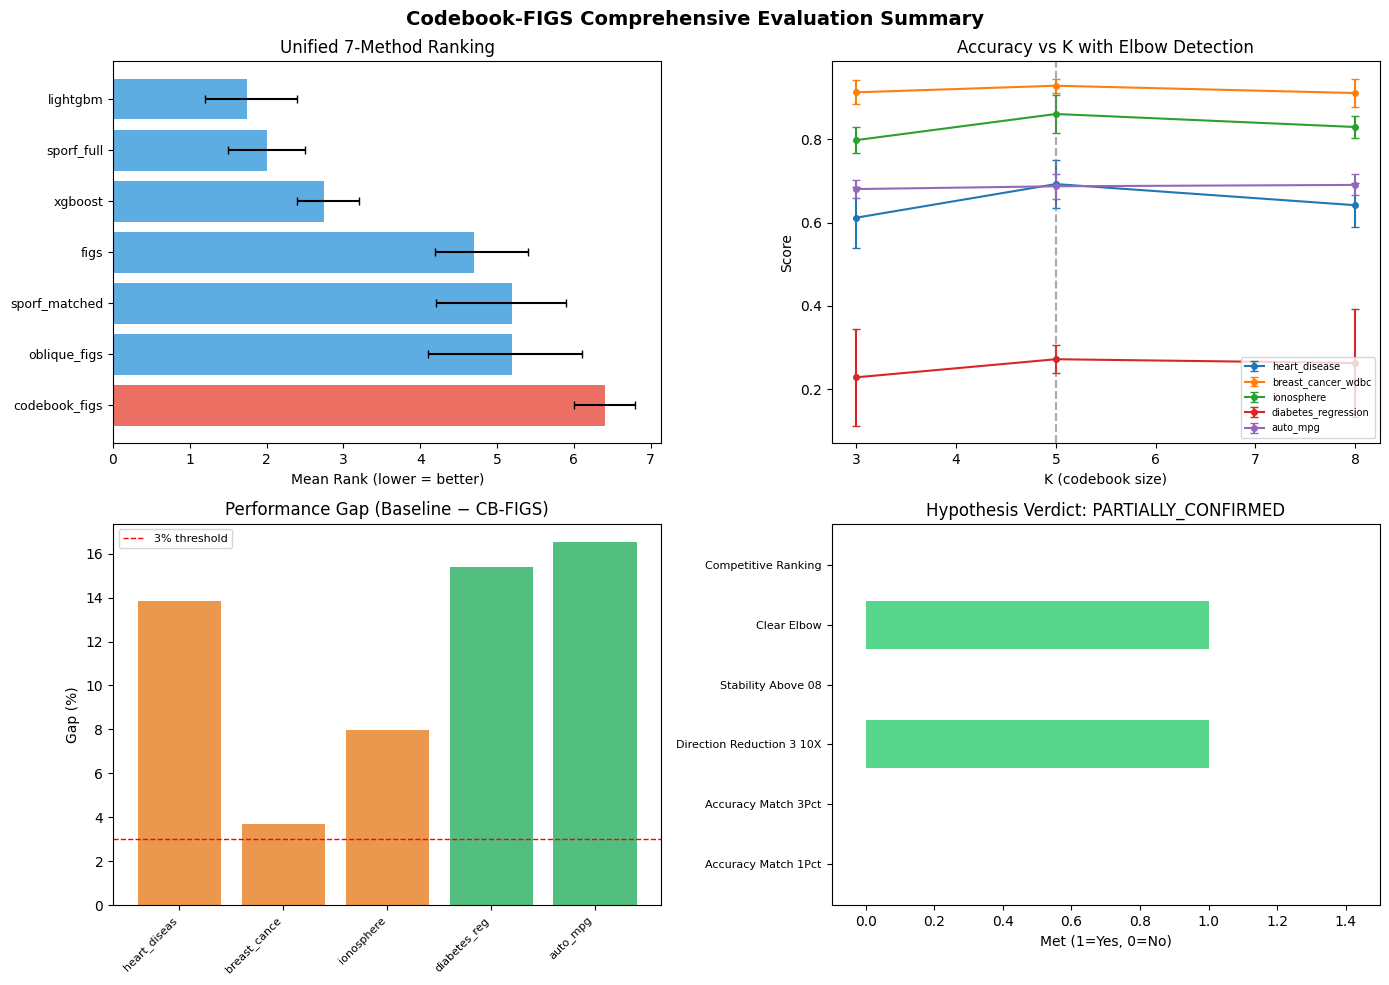

Saved evaluation_summary.png


In [14]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Codebook-FIGS Comprehensive Evaluation Summary", fontsize=14, fontweight="bold")

# ── Plot 1: Unified Method Ranking ──
ax = axes[0, 0]
ranking = data["metadata"]["unified_ranking"]["ranking"]
methods_sorted = sorted(ranking.items(), key=lambda x: x[1]["mean_rank"])
names = [m for m, _ in methods_sorted]
ranks = [v["mean_rank"] for _, v in methods_sorted]
ci_lo = [v["ci_lower"] for _, v in methods_sorted]
ci_hi = [v["ci_upper"] for _, v in methods_sorted]
errors = [[r - lo for r, lo in zip(ranks, ci_lo)],
          [hi - r for r, hi in zip(ranks, ci_hi)]]
colors = ["#e74c3c" if n == "codebook_figs" else "#3498db" for n in names]
ax.barh(range(len(names)), ranks, xerr=errors, color=colors, alpha=0.8, capsize=3)
ax.set_yticks(range(len(names)))
ax.set_yticklabels(names, fontsize=9)
ax.set_xlabel("Mean Rank (lower = better)")
ax.set_title("Unified 7-Method Ranking")
ax.invert_yaxis()

# ── Plot 2: Accuracy-vs-K Curves ──
ax = axes[0, 1]
for ds_name, res in accuracy_vs_k.items():
    k_vals = res["K_values"]
    means = res["mean_scores"]
    stds = res.get("std_scores", [0]*len(means))
    ax.errorbar(k_vals, means, yerr=stds, marker="o", label=ds_name,
                capsize=3, linewidth=1.5, markersize=4)
    if res.get("elbow_K"):
        elbow_idx = k_vals.index(res["elbow_K"]) if res["elbow_K"] in k_vals else None
        if elbow_idx is not None:
            ax.axvline(x=res["elbow_K"], color="gray", linestyle="--", alpha=0.3)
ax.set_xlabel("K (codebook size)")
ax.set_ylabel("Score")
ax.set_title("Accuracy vs K with Elbow Detection")
ax.legend(fontsize=7, loc="lower right")

# ── Plot 3: Gap Analysis ──
ax = axes[1, 0]
gap_data = data["metadata"]["gap_analysis"]["per_dataset"]
ds_names_gap = list(gap_data.keys())
gaps_pct = [gap_data[d]["gap_pct"] for d in ds_names_gap]
task_types = [gap_data[d]["task_type"] for d in ds_names_gap]
bar_colors = ["#e67e22" if t == "classification" else "#27ae60" for t in task_types]
bars = ax.bar(range(len(ds_names_gap)), gaps_pct, color=bar_colors, alpha=0.8)
ax.axhline(y=3.0, color="red", linestyle="--", linewidth=1, label="3% threshold")
ax.set_xticks(range(len(ds_names_gap)))
ax.set_xticklabels([d[:12] for d in ds_names_gap], rotation=45, ha="right", fontsize=8)
ax.set_ylabel("Gap (%)")
ax.set_title("Performance Gap (Baseline − CB-FIGS)")
ax.legend(fontsize=8)

# ── Plot 4: Hypothesis Criteria ──
ax = axes[1, 1]
criteria = verdict["criteria"]
crit_names = list(criteria.keys())
crit_met = [1 if criteria[c]["met"] else 0 for c in crit_names]
bar_colors = ["#2ecc71" if m else "#e74c3c" for m in crit_met]
ax.barh(range(len(crit_names)), crit_met, color=bar_colors, alpha=0.8)
ax.set_yticks(range(len(crit_names)))
ax.set_yticklabels([c.replace("_", " ").title() for c in crit_names], fontsize=8)
ax.set_xlabel("Met (1=Yes, 0=No)")
ax.set_title(f"Hypothesis Verdict: {verdict['verdict']}")
ax.set_xlim(-0.1, 1.5)

plt.tight_layout()
plt.savefig("evaluation_summary.png", dpi=100, bbox_inches="tight")
plt.show()
print("Saved evaluation_summary.png")

## Aggregate Metrics Summary

Key aggregate metrics from the full evaluation.

In [15]:
# Print aggregate metrics summary
metrics = data["metrics_agg"]

print("=" * 60)
print("COMPREHENSIVE EVALUATION SUMMARY")
print("=" * 60)
print()

rows = [
    ["Friedman chi²", f"{metrics['friedman_chi2']:.3f}"],
    ["Friedman p-value", f"{metrics['friedman_p_value']:.2e}"],
    ["Mean gap (%)", f"{metrics['mean_gap_pct']:.1f}"],
    ["Failure rate (>3% gap)", f"{metrics['failure_rate']*100:.0f}%"],
    ["Mean compression ratio", f"{metrics['mean_compression_ratio']:.2f}"],
    ["Median compression ratio", f"{metrics['median_compression_ratio']:.2f}"],
    ["Mean stability cosine", f"{metrics['mean_stability_cosine']:.3f}"],
    ["Datasets stability > 0.8", f"{metrics['n_datasets_stability_above_08']}"],
    ["Mean convergence rounds", f"{metrics['mean_convergence_rounds']:.2f}"],
    ["Clear elbows", f"{metrics['n_clear_elbows']}"],
    ["CB-FIGS unified mean rank", f"{metrics.get('codebook_figs_unified_mean_rank', 'N/A')}"],
    ["Criteria met", f"{metrics['n_criteria_met']}/{metrics['n_criteria_total']}"],
    ["Hypothesis confirmed", "YES" if metrics["hypothesis_confirmed"] else "NO"],
]
print(tabulate(rows, headers=["Metric", "Value"], tablefmt="simple"))

print()
print(f"Final verdict: {verdict['verdict']}")
print(f"  ({verdict['n_criteria_met']}/{verdict['n_criteria_total']} criteria met — "
      f"direction reduction ≥3× and clear elbows pass; "
      f"accuracy match, stability, and competitive ranking fail)")

COMPREHENSIVE EVALUATION SUMMARY

Metric                     Value
-------------------------  --------
Friedman chi²              27.667
Friedman p-value           4.27e-06
Mean gap (%)               20.9
Failure rate (>3% gap)     100%
Mean compression ratio     3.08
Median compression ratio   2.14
Mean stability cosine      0.624
Datasets stability > 0.8   1
Mean convergence rounds    3.73
Clear elbows               9
CB-FIGS unified mean rank  6.4
Criteria met               2/6
Hypothesis confirmed       NO

Final verdict: PARTIALLY_CONFIRMED
  (2/6 criteria met — direction reduction ≥3× and clear elbows pass; accuracy match, stability, and competitive ranking fail)
